In [1]:
import os
import sys
from pathlib import Path

# Ensure project root is on sys.path so 'backtester' imports work
cwd = Path(os.getcwd())
candidates = [cwd, cwd.parent, Path("..").resolve()]
for p in candidates:
    if (p / "backtester").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

print("PYTHONPATH set. Using root:", sys.path[0])

PYTHONPATH set. Using root: c:\Users\User\Desktop\Crypto strategy backtest


## Load Data

In [2]:
import pandas as pd

def load_crypto_parquet_data(coin_name: str, timeframe: str = "5m", nM: int = 54, section: str = "UTC") -> pd.DataFrame:
    df = pd.read_parquet(fr'C:\Users\User\Desktop\Crypto\{coin_name}_{timeframe}_{nM}M_{section}.parquet')
    return df
def generate_us_session_bars_info(df, include_holidays: bool = False):
    # 確保時間有時區資訊
    df['dt_ny'] = pd.to_datetime(df['dt_utc'], utc=True).dt.tz_convert('America/New_York')

    # 取日期（當地日曆）
    df['date'] = df['dt_ny'].dt.date
    df['weekday'] = df['dt_ny'].dt.day_name() 
    # 對每天依時間排序並編號
    df = df.sort_values(['date', 'dt_ny']).reset_index(drop=True)
    df['bar_index'] = df.groupby('date').cumcount() + 1  # 第幾根K線，從1開始
    if not include_holidays:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday']
    else:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    df = df.loc[df['weekday'].isin(weekday)]
    # 查看結果
    df.set_index('dt_utc', inplace=True)
    # print(df[['dt_ny', 'date', 'weekday', 'bar_index']].head(5))

    return df
def generate_allday_bars_info(df, include_holidays: bool = True):
# 確保時間有時區資訊
    df['dt_ny'] = pd.to_datetime(df['dt_utc'], utc=True).dt.tz_convert('America/New_York')

    # 取日期（當地日曆）
    df['date'] = df['dt_ny'].dt.date
    df['time'] = df['dt_ny'].dt.time
    df['weekday'] = df['dt_ny'].dt.day_name() 
    # 對每天依時間排序並編號
    df = df.sort_values(['date', 'dt_ny']).reset_index(drop=True)
    df['bar_index'] = df.groupby('date').cumcount() + 1  # 第幾根K線，從1開始
    if not include_holidays:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday']
    else:
        weekday = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    df = df.loc[df['weekday'].isin(weekday)]
    # 查看結果
    df.set_index('dt_utc', inplace=True)
    # print(df[['dt_ny', 'date', 'weekday', 'bar_index']].head(5))

    return df


In [3]:
coin_name = 'ETH'  # 可更改為 'ETH', 'SOL', 'BTC', 'ADA', 'PAXG' 等等
nM = 48
timeframe = "5m"
section = "UTC"

df = load_crypto_parquet_data(coin_name=coin_name, timeframe=timeframe, nM=nM, section=section)
df = generate_allday_bars_info(df, include_holidays=False)


## Split Data

In [4]:
# 分成n等分windows
def split_into_windows(df: pd.DataFrame, n_windows: int, overlap_ratio: float = 0.0) -> list[pd.DataFrame]:
    unique_dates = df.index.unique()
    n_dates = len(unique_dates)
    window_size = n_dates // n_windows
    windows = []
    end_idx = 0
    total_windows = (n_dates - window_size)//(int(window_size * (1 - overlap_ratio))) + 1 if overlap_ratio > 0 else n_windows
    for i in range(total_windows):
        start_idx = end_idx
        if i == total_windows - 1:  # 最後一個視窗包含剩餘的日期
            end_idx = n_dates
        if overlap_ratio > 0 and i > 0:
            overlap_size = int(window_size * overlap_ratio)
            start_idx -= overlap_size
        end_idx = start_idx + window_size
        window_dates = unique_dates[start_idx:end_idx]
        window_df = df[df.index.isin(window_dates)].copy()
        windows.append(window_df)
    return windows
def split_into_train_test(df: pd.DataFrame, train_pct: float = 0.7) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique_dates = df.index.unique()
    n_dates = len(unique_dates)
    train_size = int(n_dates * train_pct)
    train_dates = unique_dates[:train_size]
    test_dates = unique_dates[train_size:]
    train_df = df[df.index.isin(train_dates)].copy()
    test_df = df[df.index.isin(test_dates)].copy()
    return train_df, test_df

In [5]:
splited_dfs = split_into_windows(df, n_windows=20, overlap_ratio=0)
splited_train_test_dfs = [split_into_train_test(window_df, train_pct=0.7) for window_df in splited_dfs]

## Build Strategy

In [6]:
from backtester.models import Position, Side, ActionType, BacktestConfig, SizingEquityBase
from backtester.engine import BacktestEngine
from backtester.strategy_base import StrategyContext
from backtester.strategies.al_breakout_pullback_50pct import ALBreakoutPullback50pctParams, ALBreakoutPullback50pctStrategy
from typing import Any, Dict, List
from itertools import product
def build_param_combinations(grid: Dict[str, List[Any]]) -> List[Dict[str, Any]]:
    """
    將 param_grid 展開成所有組合，每個組合是一個 dict。
    grid 的值必須是 list/tuple 等 iterable。
    """
    keys = list(grid.keys())
    values_lists = [grid[k] for k in keys]
    combos = [dict(zip(keys, vals)) for vals in product(*values_lists)]
    return combos
def tune_strategy_params(train_df: pd.DataFrame, test_df: pd.DataFrame, param_grid: dict, best_n_params: int, engine) -> dict:
    best_params = None
    best_performance = -float('inf')
    params_combinations = build_param_combinations(param_grid)
        
    performance_list = []

    for params in params_combinations:
        strat_params = ALBreakoutPullback50pctParams(**params)
        strat = ALBreakoutPullback50pctStrategy(strat_params)
        train_result = engine.run(train_df, strat)
        performance = train_result.equity_curve.values[-1] - train_result.equity_curve.values[0]  # 總收益作為績效指標
        unique_days = train_df.index.normalize().unique()
        performance_per_day = performance / (len(unique_days))

        if performance_per_day > best_performance:
            best_performance = performance_per_day
        performance_list.append((params, performance_per_day, len(train_result.trades)))
    performance_list.sort(key=lambda x: x[1], reverse=True)
    best_params_list = performance_list[:best_n_params]

    train_vs_test_results = []
    for params, perf, n_trades in best_params_list:
        strat_params = ALBreakoutPullback50pctParams(**params)
        strat = ALBreakoutPullback50pctStrategy(strat_params)
        test_result = engine.run(test_df, strat)
        test_performance = test_result.equity_curve.values[-1] - test_result.equity_curve.values[0]
        unique_days = test_df.index.normalize().unique()
        test_performance_per_day = test_performance / (len(unique_days))
        perf_diff = test_performance_per_day - perf
        print(f"Params: {params}, Train Perf/Day: {perf}, Test Perf/Day: {test_performance_per_day}, Trades: {len(test_result.trades)}, Perf Diff: {perf_diff}")
        train_vs_test_results.append((params, perf, test_performance_per_day, perf_diff))

    return train_vs_test_results
def test_strategy_with_params(test_df: pd.DataFrame, params: dict, engine) -> Any:
    strat_params = ALBreakoutPullback50pctParams(**params)
    strat = ALBreakoutPullback50pctStrategy(strat_params)
    test_result = engine.run(test_df, strat)
    performance = test_result.equity_curve.values[-1] - test_result.equity_curve.values[0]
    unique_days = test_df.index.normalize().unique()
    performance_per_day = performance / (len(unique_days))
    return performance_per_day, test_result


In [7]:
cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0004, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)

In [8]:
for param, values in ALBreakoutPullback50pctParams.__annotations__.items():
      print(f"Parameter: {param} | Type: {values}")  # 查看可調參數

Parameter: break_out_series_n | Type: int
Parameter: break_out_n_bars | Type: int
Parameter: BO_n_times_atr | Type: float
Parameter: n_bar_pivot | Type: int
Parameter: pullback_ratio | Type: float
Parameter: max_notional_pct | Type: float
Parameter: min_qty | Type: float
Parameter: sl_atr_like | Type: float
Parameter: fixed_sl_pct | Type: float
Parameter: rr | Type: float
Parameter: time_exit_bars | Type: int
Parameter: allow_side | Type: Optional[Side]
Parameter: sizing_equity_base | Type: SizingEquityBase


In [9]:

# param_grid = {
#     'rr': [0.3, 0.5, 0.7],
#     'break_out_n_bars': [10, 20, 30],
#     'break_out_series_n': [3],
#     'BO_n_times_atr': [0.5, 1.0, 1.5, 2],
# }
param_grid = {
    'rr': [1.5],
    'break_out_n_bars': [4],
    'break_out_series_n': [10],
    'BO_n_times_atr': [2],
}
best_n_params = 2
best_params_list = []
start_window = 0
for i in range(start_window, len(splited_train_test_dfs)):
    print(f"=== Window {i+1} ===")
    best_params =  tune_strategy_params(
        train_df=splited_train_test_dfs[i][0],
        test_df=splited_train_test_dfs[i][1],
        param_grid=param_grid,
        best_n_params=best_n_params,
        engine=engine
    )
    # print("Best Params:")
    for params, perf, test_perf, perf_diff in best_params:
        pass
        # print(f"Params: {params}, Performance per day: {perf}, Test Performance per day: {test_perf}, Performance Difference: {perf_diff}")
    best_params_list.append(best_params)



=== Window 1 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: 0.05418967042391912, Test Perf/Day: 0.011717687291206242, Trades: 2, Perf Diff: -0.04247198313271287
=== Window 2 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: -0.27586849576420364, Test Perf/Day: 0.33371687357798996, Trades: 2, Perf Diff: 0.6095853693421935
=== Window 3 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: 0.6391200281603902, Test Perf/Day: 0.0, Trades: 0, Perf Diff: -0.6391200281603902
=== Window 4 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: 0.34363348693314666, Test Perf/Day: -4.231582504556402, Trades: 4, Perf Diff: -4.575215991489549
=== Window 5 ===
Params: {'rr': 1.5, 'break_out_n_bars': 4, 'break_out_series_n': 10, 'BO_n_times_atr': 2}, Train Perf/Day: -

In [10]:
for i in range(start_window, len(splited_train_test_dfs)):
    print(f"=== Window {i+1} Test Results ===")
    for params, train_perf, _ in best_params_list[i-start_window]:
        test_perf, test_result = test_strategy_with_params(
            test_df=splited_train_test_dfs[i][1],
            params=params,
            engine=engine
        ) 
        print(f"Test Result with Params: {params}, performance per day: {test_perf}, Trades: {len(test_result.trades)} , performance diff: {test_perf - train_perf}")

=== Window 1 Test Results ===


ValueError: too many values to unpack (expected 3)

## analytics

#### 全資料回測

0
=== Fee Rate: 0.000% ===
trades: 684
win_rate: 0.49853801169590645
profit_factor: 0.9817706349342481
sharpe_ratio: -0.03707468660537515
max_drawdown: -0.4013800431838202
mean_pnl_pct: -2.923976608187137e-05
median_pnl_pct: -0.009999999999999998
p10_pnl_pct: -0.01
p90_pnl_pct: 0.01
final profit: -527.5961239533935
   entry_time_hour        pnl                                           
                         mean          sum         max         min count
0                2 -12.530080 -1553.729878  103.977182 -105.992898   124
1                3  -9.990546  -409.612404  109.270135  -99.675462    41
2                4  21.695958   824.446411  107.127794 -104.922476    38
3                5  14.528370   246.982298  109.259208 -103.873251    17
4                6  -3.663589   -91.589724  108.199072 -102.999194    25
5                7  27.098074   867.138355  102.988894  -94.728823    32
6               10   3.418512   218.784745  100.989900 -108.144984    64
7               11  -7.695

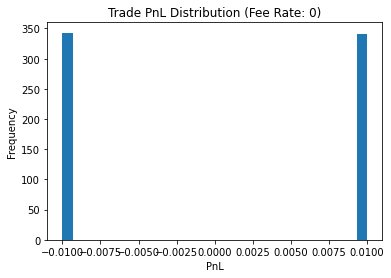

0.000125
=== Fee Rate: 0.013% ===
trades: 684
win_rate: 0.49853801169590645
profit_factor: 0.9456716762253057
sharpe_ratio: -0.3782396273360217
max_drawdown: -0.4538489560658625
mean_pnl_pct: -0.00017126794251830666
median_pnl_pct: -0.010023494460157361
p10_pnl_pct: -0.010186320100499933
p90_pnl_pct: 0.00990219205967188
final profit: -2200.4768392823653
   entry_time_hour        pnl                                           
                         mean          sum         max         min count
0                2 -12.793641 -1586.411466  101.886287 -106.815921   124
1                3 -10.341836  -424.015265  107.928119  -92.334945    41
2                4  18.007270   684.276274  105.613511 -105.933008    38
3                5  12.356383   210.058512  107.580401 -105.103444    17
4                6  -5.271890  -131.797257  106.924333 -103.946349    25
5                7  23.864177   763.653677  101.134938  -93.926685    32
6               10   1.467045    93.890874   99.532195 -108.

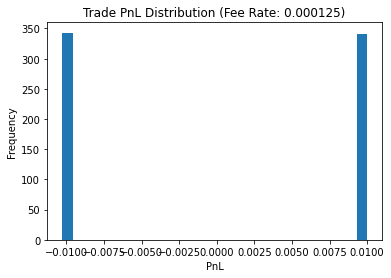

In [10]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)
rolling_backtest = False
params = ALBreakoutPullback50pctParams(
    break_out_series_n = 3, # BO定義:連續突破K線數
    break_out_n_bars = 40, # 突破區間長度（K線數）
    BO_n_times_atr= 2,
    max_notional_pct = 1, # 最大虧損佔資金比例%
    pullback_ratio= [0.5, 0.5], # 回調比例
    min_sl_range_pct= 0.8,
    n_bar_pivot= 3,  # pivot高低點定義K線數
    min_qty = 0.0001, # 最小BTC下單量
    sl_atr_like = 0.0,  # MVP不做ATR，示範保留欄位
    rr = 1,           # TP = SL距離 * rr
    time_exit_bars = 1000,
    allow_side= None,#Side.LONG,
    sizing_equity_base=SizingEquityBase.CURRENT,
)
def core_metrics(result):
    metrics = basic_metrics(result)
    equity_curve = result.equity_curve
    trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
    trade_pnl = trades_df["pnl"]
    # pnl/equity
    trade_pnl_pct = trades_df["pnl"] / equity_curve.shift(1).reindex(trades_df["entry_time"]).values
    trades = len(trades_df)
    win_rate = metrics['win_rate']
    profit_factor = metrics['profit_factor']
    sharpe_ratio = metrics['sharpe_ratio']
    MDD = metrics['max_drawdown']
    mean_pnl_pct = trade_pnl_pct.mean()
    median_pnl_pct = trade_pnl_pct.median()
    p10_pnl_pct = trade_pnl_pct.quantile(0.1)
    p90_pnl_pct = trade_pnl_pct.quantile(0.9)
    return {
        'trades': trades,
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': MDD,
        'mean_pnl_pct': mean_pnl_pct,
        'median_pnl_pct': median_pnl_pct,
        'p10_pnl_pct': p10_pnl_pct,
        'p90_pnl_pct': p90_pnl_pct,
    }
if rolling_backtest == False:
    for fee_rate in [0, 0.000125]:
        strategy = ALBreakoutPullback50pctStrategy(params)
        cfg2 = replace(cfg, fee_rate=fee_rate)
        engine = BacktestEngine(cfg2)
        print(engine.config.fee_rate)
        result = engine.run(df, strategy)
        metrics = basic_metrics(result)
        print(f"=== Fee Rate: {fee_rate*100:.3f}% ===")
        for k, v in metrics.items():
            if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio']:
                # print(f"{k}: {v}")
                pass
        for k, v in core_metrics(result).items():
            print(f"{k}: {v}")
        print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
        trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
        trade_pnl = trades_df["pnl"]
        trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
        trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
        print(trade_grouped)
        trade_pnl_pct = trades_df["pnl"] / result.equity_curve.shift(1).reindex(trades_df["entry_time"]).values

        plt.hist(trade_pnl_pct, bins=30)
        plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.show()


In [8]:
params.__dict__

{'break_out_series_n': 3,
 'break_out_n_bars': 40,
 'BO_n_times_atr': 2,
 'n_bar_pivot': 3,
 'pullback_ratio': [0.2, 0.3],
 'min_sl_range_pct': 0.8,
 'max_notional_pct': 1,
 'min_qty': 0.0001,
 'sl_atr_like': 0.0,
 'fixed_sl_pct': 0.01,
 'rr': 1.5,
 'time_exit_bars': 1000,
 'allow_side': None,
 'sizing_equity_base': <SizingEquityBase.CURRENT: 'current'>}

In [11]:
trades = pd.DataFrame([t.__dict__ for t in result.trades])
# trades.to_excel(r"C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\trades info\trades.xlsx", index=False)
print(trades["entry_time"][0])
trades["entry_time"] = trades["entry_time"].dt.tz_localize(None)
print(trades["entry_time"][0])

trades["exit_time"] = trades["exit_time"].dt.tz_localize(None)
from datetime import datetime
def export_excel_with_txt(df: pd.DataFrame, xlsx_path: str, params: dict):
    xlsx_path = Path(xlsx_path)
    df.to_excel(xlsx_path, index=False)
    print(f"Exported trades to {xlsx_path}")

    txt_path = xlsx_path.with_suffix(".params.txt")
    print(txt_path)
    lines = [
        f"created_at={datetime.now().isoformat(timespec='seconds')}",
        f"pandas_version={pd.__version__}",
    ]
    for k, v in params.items():
        lines.append(f"{k}={v}")

    txt_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return str(xlsx_path), str(txt_path)
export_excel_with_txt(trades, fr"C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\trades info\{coin_name}_{timeframe}_trades_V3.xlsx", params.__dict__)

2022-01-27 03:00:00+00:00
2022-01-27 03:00:00
Exported trades to C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\trades info\ETH_5m_trades_V3.xlsx
C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\trades info\ETH_5m_trades_V3.params.txt


('C:\\Users\\User\\Desktop\\Crypto strategy backtest 分析\\BreakoutPullback_pct\\trades info\\ETH_5m_trades_V3.xlsx',
 'C:\\Users\\User\\Desktop\\Crypto strategy backtest 分析\\BreakoutPullback_pct\\trades info\\ETH_5m_trades_V3.params.txt')

In [ ]:
import numpy as np
trades = pd.DataFrame([t.__dict__ for t in result.trades])
trades["pnl_pct"] = trades["pnl"] / result.equity_curve.shift(1).reindex(trades["entry_time"]).values
trade_grouped = trades.groupby('exit_type').agg({'pnl': ['mean', 'sum', 'max', 'min']}).reset_index()
trades["win"] = trades["pnl"] > 0
trade_long = trades[trades['side'] == Side.LONG]
trade_short = trades[trades['side'] == Side.SHORT]
## 連敗計算
trades["loss_streak"] = (trades['win'] == False).astype(int).groupby((trades['win'] != trades['win'].shift()).cumsum()).cumsum()
trade_long['loss_streak'] = (trade_long['win'] == False).astype(int).groupby((trade_long['win'] != trade_long['win'].shift()).cumsum()).cumsum()
trade_short['loss_streak'] = (trade_short['win'] == False).astype(int).groupby((trade_short['win'] != trade_short['win'].shift()).cumsum()).cumsum()

trades["SL_range"] = abs(trades["entry_price"] - trades["sl_price"])/trades["entry_price"] * 100

print("All Trades Max Loss Streaks:", trades['loss_streak'].max())
print("Long Trades Max Loss Streaks:", trade_long['loss_streak'].max())
print("Short Trades Max Loss Streaks:", trade_short['loss_streak'].max())

## 日內累計虧損計算
trades['entry_date'] = trades['entry_time'].dt.date
daily_pnl = trades.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl['cum_daily_loss'] = daily_pnl['pnl_pct']
trade_long['entry_date'] = trade_long['entry_time'].dt.date
daily_pnl_long = trade_long.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl_long['cum_daily_loss'] = daily_pnl_long['pnl_pct']
trade_short['entry_date'] = trade_short['entry_time'].dt.date
daily_pnl_short = trade_short.groupby('entry_date')['pnl_pct'].sum().reset_index()
daily_pnl_short['cum_daily_loss'] = daily_pnl_short['pnl_pct']
print("All Trades Max Daily Cumulative Loss:", daily_pnl['cum_daily_loss'].min())
print("Long Trades Max Daily Cumulative Loss:", daily_pnl_long['cum_daily_loss'].min())
print("Long Trades Daily Cumulative < 1.5% Days:", (daily_pnl_long['cum_daily_loss'] < -0.015).sum())
print("Long Trades Daily Cumulative < 2% Days:", (daily_pnl_long['cum_daily_loss'] < -0.02).sum())
print("Short Trades Max Daily Cumulative Loss:", daily_pnl_short['cum_daily_loss'].min())
plt.hist(trades["SL_range"], bins=20)
plt.title("Stop Loss Range Distribution")
plt.xlabel("SL Range")
plt.ylabel("Frequency")
plt.xticks(np.arange(0, 5, 0.3), rotation=45)
plt.grid()
plt.show()

for t in [daily_pnl, daily_pnl_long, daily_pnl_short]:
    plt.hist(t['cum_daily_loss'], bins=30)
    plt.title("Daily Cumulative PnL Distribution")
    plt.xlabel("Cumulative PnL")
    plt.ylabel("Frequency")
    plt.show()


print(trade_grouped)
# plt.hist(sort_pnls, bins=100)
# plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
coin_curve = df.groupby(df.index).last()['close']
equity_curve = result.equity_curve
plt.figure(figsize=(12, 8))
# subplot equity curve and coin price
plt.subplot(2, 1, 1)
log_equity = np.log(equity_curve / equity_curve.iloc[0])
log_coin = np.log(coin_curve / coin_curve.iloc[0])
plt.plot(equity_curve.index, log_equity, label='Log Equity Curve')
plt.plot(coin_curve.index, log_coin, label='Log Coin Price')
drawdown_pct = (equity_curve.cummax() - equity_curve) / equity_curve.cummax()
drawdown = equity_curve.cummax() - equity_curve
max_drawdown = drawdown_pct.max()
plt.title('Equity Curve and Coin Price')
plt.xlabel('Time')
plt.ylabel('Equity')
plt.legend()
print(f"Max Drawdown: {max_drawdown}")
## subplot drawdown
plt.subplot(2, 1, 2)
plt.plot(drawdown_pct.index, drawdown_pct.values, label='drawdown_pct', color='red')
plt.title('Drawdown')
plt.xlabel('Time')
plt.ylabel('Drawdown')
plt.legend()



plt.show()

#### 蒙地卡羅回測

0
=== Fee Rate: 0.000% ===
trades: 1008
win_rate: 0.439484126984127
profit_factor: 1.203470376421647
sharpe_ratio: 1.2903670978762456
max_drawdown: -0.16803917104842284
mean_pnl_pct: 0.0011068853367226996
median_pnl_pct: -0.007981991096387073
p10_pnl_pct: -0.01076278556245922
p90_pnl_pct: 0.015817470794392503
final profit: 18427.814385306625
   entry_time_hour        pnl                                           
                         mean          sum         max         min count
0                2  28.611508  3719.496020  387.064391 -320.703160   130
1                3 -36.618681 -1830.934061  495.779303 -309.470697    50
2                4  -0.611442   -39.743756  432.198461 -292.560325    65
3                5 -13.268690  -610.359737  412.445113 -288.638353    46
4                6  20.858063   855.180568  373.207007 -362.939173    41
5                7  20.005150   980.252340  378.732795 -412.518370    49
6               10  21.746063  2087.622084  442.425554 -341.087568    96

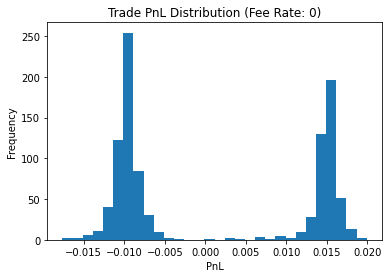

In [28]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)
rolling_backtest = False
params = ALBreakoutPullback50pctParams(
    break_out_series_n = 3, # BO定義:連續突破K線數
    break_out_n_bars = 40, # 突破區間長度（K線數）
    BO_n_times_atr= 2,
    max_notional_pct = 1, # 最大虧損佔資金比例%
    pullback_ratio= [0.2, 0.3], # 回調比例
    min_sl_range_pct= 0.8,
    n_bar_pivot= 3,  # pivot高低點定義K線數
    min_qty = 0.0001, # 最小BTC下單量
    sl_atr_like = 0.0,  # MVP不做ATR，示範保留欄位
    rr = 1.5,           # TP = SL距離 * rr
    time_exit_bars = 1000,
    allow_side= None,#Side.LONG,
    sizing_equity_base=SizingEquityBase.CURRENT,
)
def core_metrics(result):
    metrics = basic_metrics(result)
    equity_curve = result.equity_curve
    trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
    trade_pnl = trades_df["pnl"]
    # pnl/equity
    trade_pnl_pct = trades_df["pnl"] / equity_curve.shift(1).reindex(trades_df["entry_time"]).values
    trades = len(trades_df)
    win_rate = metrics['win_rate']
    profit_factor = metrics['profit_factor']
    sharpe_ratio = metrics['sharpe_ratio']
    MDD = metrics['max_drawdown']
    mean_pnl_pct = trade_pnl_pct.mean()
    median_pnl_pct = trade_pnl_pct.median()
    p10_pnl_pct = trade_pnl_pct.quantile(0.1)
    p90_pnl_pct = trade_pnl_pct.quantile(0.9)
    return {
        'trades': trades,
        'win_rate': win_rate,
        'profit_factor': profit_factor,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': MDD,
        'mean_pnl_pct': mean_pnl_pct,
        'median_pnl_pct': median_pnl_pct,
        'p10_pnl_pct': p10_pnl_pct,
        'p90_pnl_pct': p90_pnl_pct,
    }
if rolling_backtest == False:
    for fee_rate in [0]:
        strategy = ALBreakoutPullback50pctStrategy(params)
        cfg2 = replace(cfg, fee_rate=fee_rate)
        engine = BacktestEngine(cfg2)
        print(engine.config.fee_rate)
        result = engine.run(df, strategy)
        metrics = basic_metrics(result)
        print(f"=== Fee Rate: {fee_rate*100:.3f}% ===")
        for k, v in metrics.items():
            if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio']:
                # print(f"{k}: {v}")
                pass
        for k, v in core_metrics(result).items():
            print(f"{k}: {v}")
        print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
        trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
        trade_pnl = trades_df["pnl"]
        trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
        trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
        print(trade_grouped)
        trade_pnl_pct = trades_df["pnl"] / result.equity_curve.shift(1).reindex(trades_df["entry_time"]).values

        plt.hist(trade_pnl_pct, bins=30)
        plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.show()


In [26]:
trades_df["pnl_pct"] = trades_df["pnl"] / result.equity_curve.shift(1).reindex(trades_df["entry_time"]).values

Ruin Rate (MDD < -50%): 74.90%
Average MDD: -56.50%
Worst MDD: -84.26%
Best MDD: -35.38%
Average Max Loss Streak: 11.12
Worst Max Loss Streak: 23
Best Max Loss Streak: 7


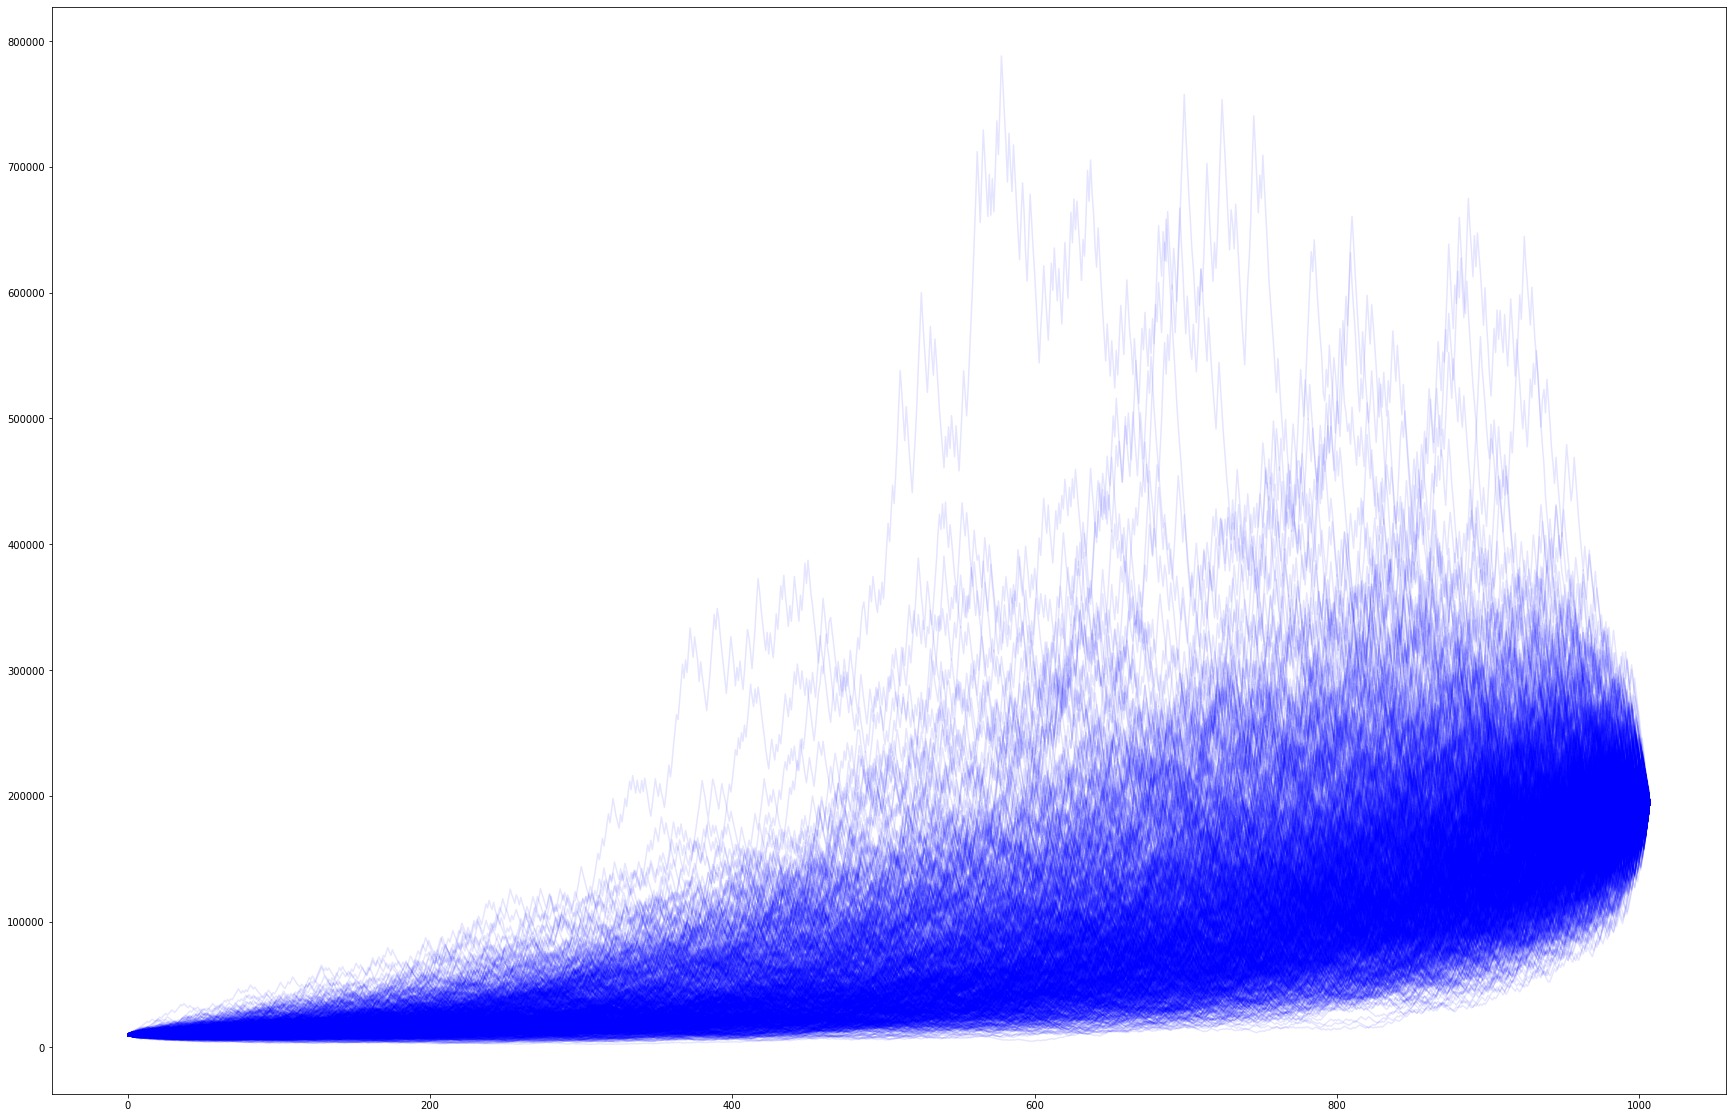

In [27]:
## randomly shuffle pnl_pct
import numpy as np
random_times = 1000
initial_equity = result.equity_curve.values[0]
monte_carlo_results = {
    "final_return": [],
    "mean_pnl_pct": [],
    "median_pnl_pct": [],
    "MDD": [],
    "Max loss streak": [],
    "equity_curves": [],  # 儲存每次模擬的 equity curve
}
plt.figure(figsize=(30, 20))
for i in range(random_times):
    monte_carlo_df = trades_df.copy()
    random_seed = i  # 每次迭代使用不同的随机种子
    np.random.seed(random_seed)
    monte_carlo_df["pnl_pct"] = np.random.permutation(monte_carlo_df["pnl_pct"].values)
    monte_carlo_df["equity"] = initial_equity * (1 + monte_carlo_df["pnl_pct"]).cumprod()
    final_return = monte_carlo_df["equity"].iloc[-1] - initial_equity
    mean_pnl_pct = monte_carlo_df["pnl_pct"].mean()
    median_pnl_pct = monte_carlo_df["pnl_pct"].median()
    drawdown = monte_carlo_df["equity"].cummax() - monte_carlo_df["equity"]
    drawdown_pct = drawdown / monte_carlo_df["equity"].cummax()
    MDD = drawdown_pct.max()
    monte_carlo_results["final_return"].append(final_return)
    monte_carlo_results["mean_pnl_pct"].append(mean_pnl_pct)
    monte_carlo_results["median_pnl_pct"].append(median_pnl_pct)
    monte_carlo_results["MDD"].append(-MDD)
    # 連敗計算
    monte_carlo_df["win"] = monte_carlo_df["pnl_pct"] > 0
    monte_carlo_df["loss_streak"] = (monte_carlo_df['win'] == False).astype(int).groupby((monte_carlo_df['win'] != monte_carlo_df['win'].shift()).cumsum()).cumsum()
    max_loss_streak = monte_carlo_df['loss_streak'].max()
    monte_carlo_results["Max loss streak"].append(max_loss_streak)
    monte_carlo_results["equity_curves"].append(monte_carlo_df["equity"].values)
    # 細線
    plt.plot(monte_carlo_df["equity"].values, color='blue', alpha=0.1)
monte_carlo_results_df = pd.DataFrame(monte_carlo_results)
ruin_rate = (monte_carlo_results_df["MDD"] < -0.5).mean()
avg_MDD = monte_carlo_results_df["MDD"].mean()
worst_MDD = monte_carlo_results_df["MDD"].min()
best_MDD = monte_carlo_results_df["MDD"].max()
avg_loss_streak = monte_carlo_results_df["Max loss streak"].mean()
worst_loss_streak = monte_carlo_results_df["Max loss streak"].max()
best_loss_streak = monte_carlo_results_df["Max loss streak"].min()
print(f"Ruin Rate (MDD < -50%): {ruin_rate*100:.2f}%")
print(f"Average MDD: {avg_MDD*100:.2f}%")
print(f"Worst MDD: {worst_MDD*100:.2f}%")
print(f"Best MDD: {best_MDD*100:.2f}%")
print(f"Average Max Loss Streak: {avg_loss_streak:.2f}")
print(f"Worst Max Loss Streak: {worst_loss_streak}")
print(f"Best Max Loss Streak: {best_loss_streak}")

plt.show()



#### Rolling 回測

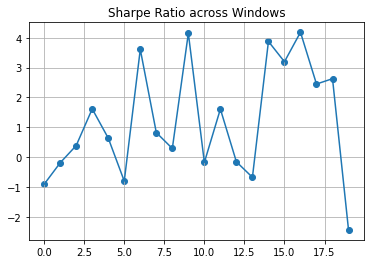

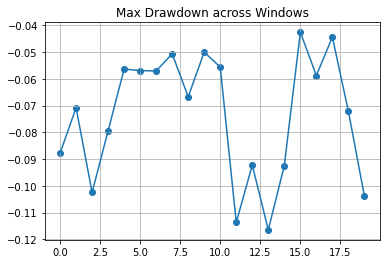

In [ ]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
cfg = BacktestConfig(initial_cash=10000, fee_rate=0.0002, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)
rolling_backtest = False
params = ALBreakoutPullback50pctParams(
    break_out_series_n = 3, # BO定義:連續突破K線數
    break_out_n_bars = 40, # 突破區間長度（K線數）
    BO_n_times_atr= 2,
    max_notional_pct = 1, # 最大虧損佔資金比例%
    pullback_ratio= [0.2, 0.3], # 回調比例
    min_sl_range_pct= 0.8,
    n_bar_pivot= 3,  # pivot高低點定義K線數
    min_qty = 0.0001, # 最小BTC下單量
    sl_atr_like = 0.0,  # MVP不做ATR，示範保留欄位
    rr = 1.5,           # TP = SL距離 * rr
    time_exit_bars = 1000,
    allow_side= None,#Side.LONG,
    sizing_equity_base=SizingEquityBase.CURRENT,
)
if rolling_backtest == True:
    all_metrics = {}
    for fee_rate in [0.00005]:
        for window_idx in range(len(splited_train_test_dfs)):
            print(f"=== Window {window_idx+1} ===")
            strategy = ALBreakoutPullback50pctStrategy(params)
            cfg2 = replace(cfg, fee_rate=fee_rate)
            engine = BacktestEngine(cfg2)
            print(engine.config.fee_rate)
            result = engine.run(splited_dfs[window_idx], strategy)
            metrics = basic_metrics(result)
            print(f"=== Fee Rate: {fee_rate} ===")
            for k, v in metrics.items():
                if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio', 'avg_win_held_bars', 'avg_loss_held_bars']:
                    # print(f"{k}: {v}")
                    pass
            for k, v in core_metrics(result).items():
                print(f"{k}: {v}")
                all_metrics.setdefault(k, []).append(v)
            print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
            trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
            trade_pnl = trades_df["pnl"]
            trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
            trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
            print(trade_grouped)
            # plt.hist(trade_pnl, bins=30)
            # plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
            # plt.xlabel("PnL")
            # plt.ylabel("Frequency")
            # plt.show()
    all_metrics_df = pd.DataFrame(all_metrics)
    all_metrics_df.describe() 

plt.scatter(all_metrics_df.index, all_metrics_df['sharpe_ratio'])
plt.plot(all_metrics_df.index, all_metrics_df['sharpe_ratio'])
plt.title("Sharpe Ratio across Windows")
plt.grid()
plt.show()

plt.scatter(all_metrics_df.index, all_metrics_df['max_drawdown'])
plt.plot(all_metrics_df.index, all_metrics_df['max_drawdown'])
plt.title("Max Drawdown across Windows")
plt.grid()
plt.show()

### Params Heatmap

In [ ]:
from backtester.analytics import basic_metrics
from dataclasses import replace
import matplotlib.pyplot as plt
import numpy as np

cfg = BacktestConfig(initial_cash=10000, fee_rate=0.000125, slippage_bps=0.0, conservative_intrabar=True)
engine = BacktestEngine(cfg)
rolling_backtest = False
params = ALBreakoutPullback50pctParams(
    break_out_series_n = 3, # BO定義:連續突破K線數
    break_out_n_bars = 30, # 突破區間長度（K線數）
    BO_n_times_atr= 2,
    max_notional_pct = 1, # 最大虧損佔資金比例%
    pullback_ratio= [0.2, 0.3], # 回調比例
    min_sl_range_pct= 0.6,
    n_bar_pivot= 3,  # pivot高低點定義K線數
    min_qty = 0.0001, # 最小BTC下單量
    sl_atr_like = 0.0,  # MVP不做ATR，示範保留欄位
    rr = 1,           # TP = SL距離 * rr
    time_exit_bars = 1000,
    allow_side=None,
    sizing_equity_base=SizingEquityBase.CURRENT,
)
param_name = "min_sl_range_pct"
param_values = np.arange(0.2, 1.2, 0.2)
all_metrics = {}
if rolling_backtest == False:
    for param_value in param_values:
        params = replace(params, **{param_name: param_value})
        strategy = ALBreakoutPullback50pctStrategy(params)
        engine = BacktestEngine(cfg)
        result = engine.run(df, strategy)
        metrics = basic_metrics(result)
        print(f"=== {param_name}: {param_value} ===")
        all_metrics.setdefault(param_name, []).append(param_value)
        for k, v in metrics.items():
            if k in ['total_days', 'trades', 'win_rate', 'profit_factor', 'max_drawdown', 'sharpe_ratio']:
                all_metrics.setdefault(k, []).append(v)
                print(f"{k}: {v}")
        print(f"final profit: {result.equity_curve.values[-1] - result.equity_curve.values[0]}")
        trades_df = pd.DataFrame([t.__dict__ for t in result.trades])
        trade_pnl = trades_df["pnl"]
        # trades_df["entry_time_hour"] = trades_df["entry_time"].dt.hour
        # trade_grouped = trades_df.groupby('entry_time_hour').agg({'pnl': ['mean', 'sum', 'max', 'min', 'count']}).reset_index()
        # print(trade_grouped)

        # plt.hist(trade_pnl, bins=30)
        # plt.title(f"Trade PnL Distribution (Fee Rate: {fee_rate})")
        # plt.xlabel("PnL")
        # plt.ylabel("Frequency")
        # plt.show()

    all_metrics_df = pd.DataFrame(all_metrics)
print(all_metrics_df)

=== min_sl_range_pct: 0.2 ===
trades: 1846.0
win_rate: 0.5390032502708559
profit_factor: 1.1656607637449823
max_drawdown: -0.18776358780252933
sharpe_ratio: 1.2409301985576953
total_days: 1440.0
final profit: 18804.05041437939
=== min_sl_range_pct: 0.4 ===
trades: 1699.0
win_rate: 0.5373749264273102
profit_factor: 1.1674925630371393
max_drawdown: -0.17339102024724387
sharpe_ratio: 1.1767814681911135
total_days: 1440.0
final profit: 16111.056388112152
=== min_sl_range_pct: 0.6000000000000001 ===
trades: 1462.0
win_rate: 0.53077975376197
profit_factor: 1.1367733869394518
max_drawdown: -0.21843533509184332
sharpe_ratio: 0.9179346578200324
total_days: 1440.0
final profit: 10193.362838171528
=== min_sl_range_pct: 0.8 ===
trades: 1195.0
win_rate: 0.5230125523012552
profit_factor: 1.1107168742937679
max_drawdown: -0.15480867097913384
sharpe_ratio: 0.6648215653126828
total_days: 1440.0
final profit: 5769.385763341721
=== min_sl_range_pct: 1.0 ===
trades: 957.0
win_rate: 0.5130616509926855
prof

In [13]:
all_metrics_df.to_excel(rf"C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\pullback_ratio\tune_pullback_ratio.xlsx")

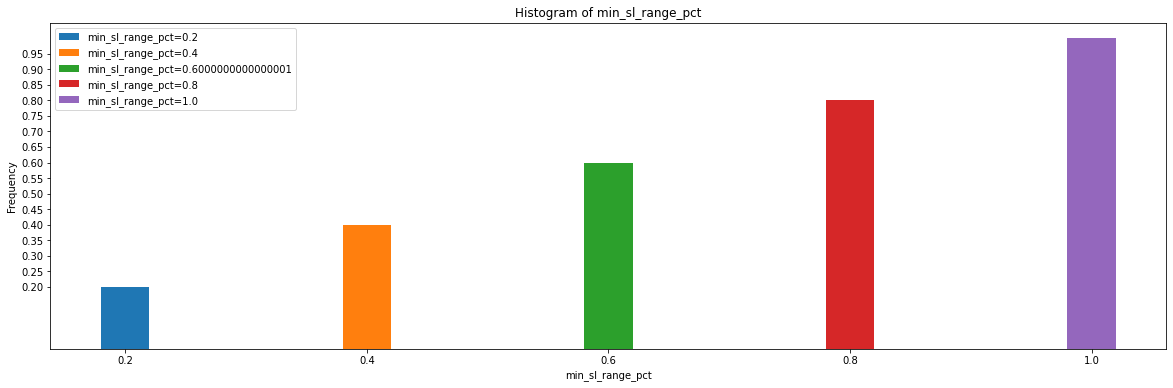

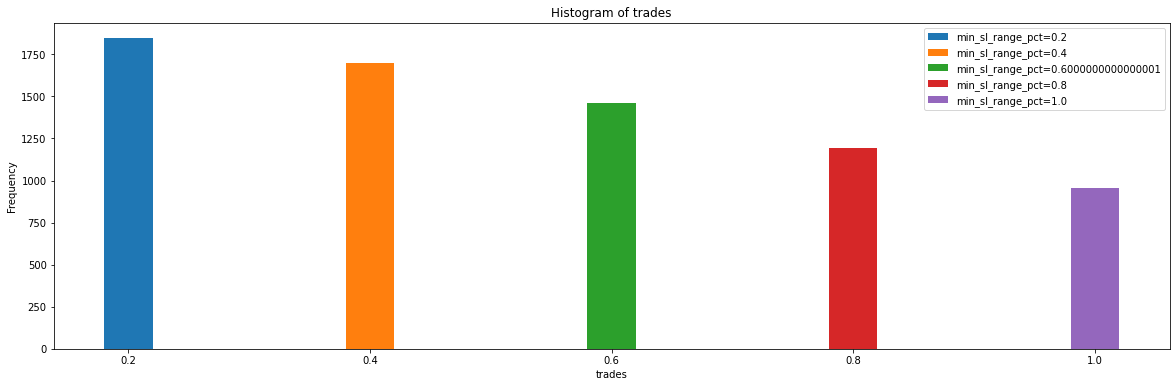

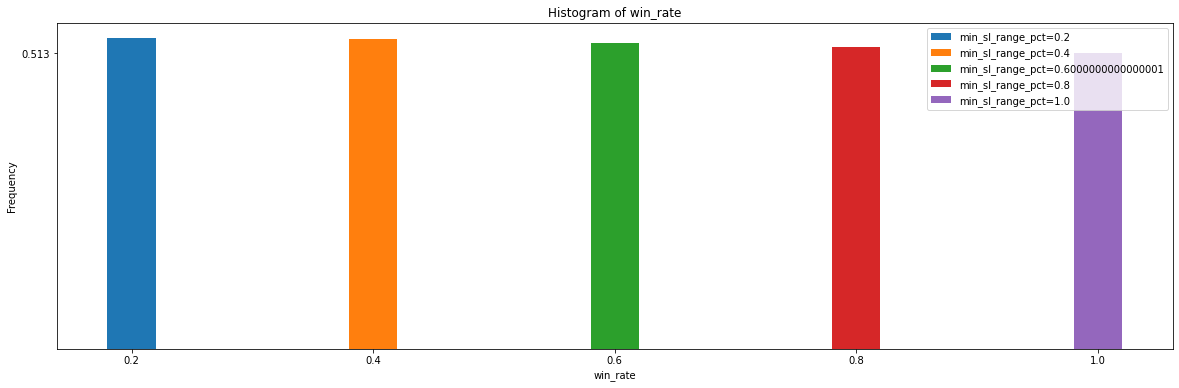

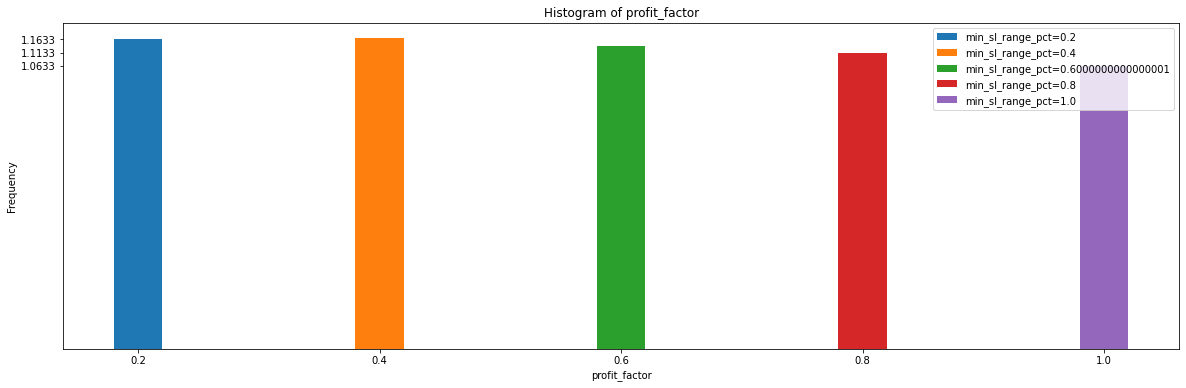

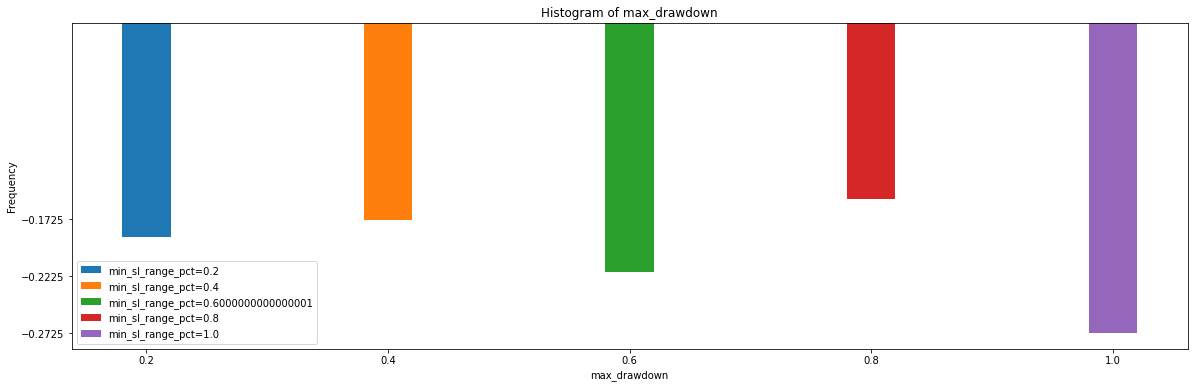

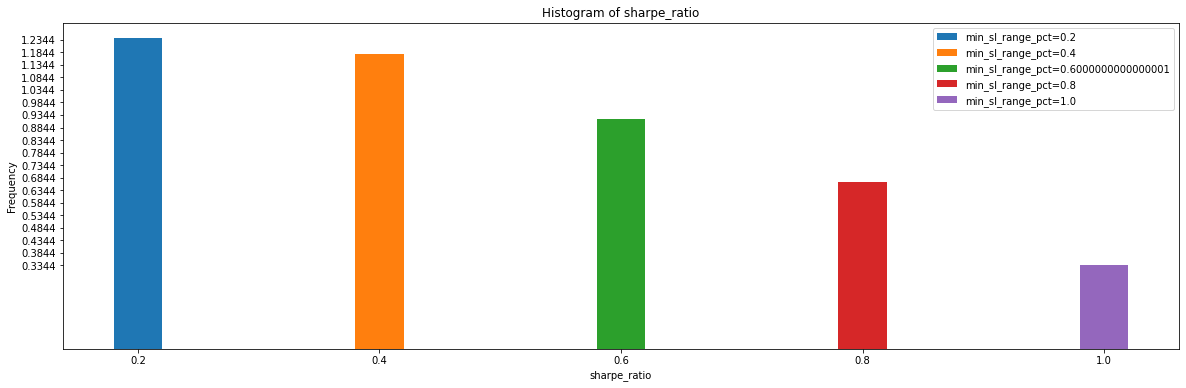

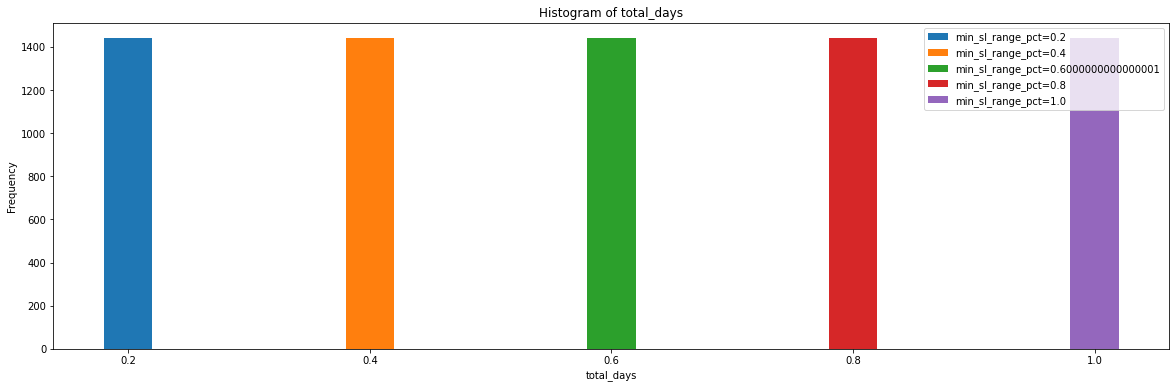

In [58]:
import matplotlib.pyplot as plt

## Draw
for metric in all_metrics_df.columns:
    plt.figure(figsize=(20, 6))
    for param_value in all_metrics_df[param_name].unique():
        subset = all_metrics_df[all_metrics_df[param_name] == param_value]
        # plot bar for each metric
        bar_x = param_value
        width = 0.04
        plt.bar(bar_x, subset[metric].values[0], width=width, label=f"{param_name}={param_value}")
    plt.title(f"Histogram of {metric}")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    if metric not in ['trades', 'total_days']:
        plt.yticks(np.arange(all_metrics_df[metric].min(), all_metrics_df[metric].max(), step=0.05))
    plt.legend()
    # plt.savefig(rf"C:\Users\User\Desktop\Crypto strategy backtest 分析\BreakoutPullback_pct\pullback_ratio\{metric}_vs_{param_name}.png", dpi=300, bbox_inches='tight')
    plt.show()